NOTE: Dataset was obtained from the following paper: Y. Siriwardhana et al., "Descriptor: 5G Wireless Network Intrusion Detection Dataset (5G-NIDD)," in IEEE Data Descriptions, doi: 10.1109/IEEEDATA.2025.3592888.

Dataset was downloaded here: https://etsin.fairdata.fi/dataset/9d13ef28-2ca7-44b0-9950-225359afac65 

# Incremental Learning - Learning without Forgetting

Uses the same Multi Layer Perceptron as the notebook that has IncrementalLearning_Naive but this time it includes a knowledge distillation penalty during batch training.

In [ ]:
# Importing libraries and paths
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Paths
DATA_DIR = "../data"
MODELS_DIR = "../models"
OUT_DIR = "../outputs"
METRICS_FILE = os.path.join(DATA_DIR, "comparison_metrics.json")
LABEL_ENCODER_PATH = os.path.join(MODELS_DIR, "label_encoder.pkl")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("OUT_DIR:", OUT_DIR)
print("METRICS_FILE:", METRICS_FILE)


DATA_DIR: ../data
MODELS_DIR: ../models
OUT_DIR: ../outputs
METRICS_FILE: ../data/comparison_metrics.json


In [ ]:
# Load encoded inputs and targets
X_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_encoded.csv"))
y_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_target.csv"))

X_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_encoded.csv"))
y_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_target.csv"))

# flatten label frames if needed
y_old = y_old_df.iloc[:,0].values if isinstance(y_old_df, pd.DataFrame) else y_old_df.values
y_new = y_new_df.iloc[:,0].values if isinstance(y_new_df, pd.DataFrame) else y_new_df.values

X_old = X_old_df.values
X_new = X_new_df.values

print("Loaded shapes:")
print("  X_old:", X_old.shape, "y_old:", y_old.shape)
print("  X_new:", X_new.shape, "y_new:", y_new.shape)


Loaded shapes:
  X_old: (728316, 112) y_old: (728316,)
  X_new: (487574, 112) y_new: (487574,)


In [ ]:
# LabelEncoder (reuse if exists) and type casting
if os.path.exists(LABEL_ENCODER_PATH):
    le = joblib.load(LABEL_ENCODER_PATH)
    print("Loaded LabelEncoder from", LABEL_ENCODER_PATH)
else:
    le = LabelEncoder()
    le.fit(np.concatenate([y_old, y_new]))
    joblib.dump(le, LABEL_ENCODER_PATH)
    print("Fitted and saved new LabelEncoder to", LABEL_ENCODER_PATH)

y_old_enc = le.transform(y_old).astype(np.int64)
y_new_enc = le.transform(y_new).astype(np.int64)

# cast features to float32 for PyTorch
X_old = X_old.astype(np.float32)
X_new = X_new.astype(np.float32)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)


Loaded LabelEncoder from ../models/label_encoder.pkl
Number of classes: 2


In [ ]:
# Split X_old into train/test so we have a held-out old test set
from sklearn.model_selection import train_test_split
X_old_train, X_old_test, y_old_train, y_old_test = train_test_split(
    X_old, y_old_enc, test_size=0.2, random_state=42, stratify=y_old_enc
)
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)


X_old_train: (582652, 112) X_old_test: (145664, 112)


In [ ]:
# Define model and helpers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_size=16, output_dim=None):
        super().__init__()
        if output_dim is None:
            raise ValueError("output_dim must be provided")
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size//2)
        self.fc_out = nn.Linear(hidden_size//2, output_dim)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc_out(x)

def predict_proba_and_pred(model, X_np):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_np, dtype=torch.float32, device=device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return probs, preds

def evaluate_acc(model, X_np, y_np):
    _, preds = predict_proba_and_pred(model, X_np)
    return (preds == y_np).mean()

# Initialize student model, criterion, optimizer (we'll re-init if testing alphas)
student = MLP(X_old.shape[1], hidden_size=128, output_dim=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
student_optimizer = optim.Adam(student.parameters(), lr=1e-3)



Using device: cpu


In [ ]:
# Simple training for teacher (offline BTS2)
def train_offline(model, X_tr, y_tr, epochs=10, batch_size=128, optimizer=None):
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    n = X_tr.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        X_shuf = X_tr[perm]
        y_shuf = y_tr[perm]
        for i in range(0, n, batch_size):
            xb = torch.tensor(X_shuf[i:i+batch_size], dtype=torch.float32, device=device)
            yb = torch.tensor(y_shuf[i:i+batch_size], dtype=torch.long, device=device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
    return model



In [ ]:
# LwF incremental training (one pass over a batch) that records per-batch accuracies
def incremental_train_lwf(student, teacher, X_new, y_new, alpha=0.7,
                        batch_size=128, epochs=2, optimizer=None, device=device):
    """
    Incremental LwF training with batch-wise updates.
    Evaluates accuracy only at intervals (~50 times total) to reduce runtime.
    """
    student.train()
    n_samples = X_new.shape[0]

    # Compute total batches and evaluation interval
    total_batches = ((n_samples - 1)//batch_size + 1) * epochs
    eval_interval = max(1, total_batches // 50)  # evaluate ~50 times total

    acc_old_batches = []
    acc_new_batches = []
    batch_idx = []
    counter = 0

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_stream = X_new[perm]
        y_stream = y_new[perm]

        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            xb = torch.tensor(X_stream[start:end], dtype=torch.float32, device=device)
            yb = torch.tensor(y_stream[start:end], dtype=torch.long, device=device)

            optimizer.zero_grad()
            logits_student = student(xb)
            with torch.no_grad():
                logits_teacher = teacher(xb)

            ce_loss = nn.CrossEntropyLoss()(logits_student, yb)
            soft_targets = torch.softmax(logits_teacher / 2.0, dim=1)
            distill_loss = nn.KLDivLoss(reduction='batchmean')(
                torch.log_softmax(logits_student / 2.0, dim=1), soft_targets
            )
            loss = alpha * distill_loss + (1 - alpha) * ce_loss

            loss.backward()
            optimizer.step()
            counter += 1

            if counter % eval_interval == 0 or counter == 1:
                acc_old_now = evaluate_acc(student, X_old_test, y_old_test)
                acc_new_now = evaluate_acc(student, X_new, y_new_enc)
                acc_old_batches.append(acc_old_now)
                acc_new_batches.append(acc_new_now)
                batch_idx.append(counter)
                print(f"[LwF] batch {counter} | BTS2_test acc: {acc_old_now:.4f} | BTS1 acc: {acc_new_now:.4f}")

    return acc_old_batches, acc_new_batches, batch_idx


In [ ]:
# Run LwF experiment (reduced epochs + bigger student)
alphas_to_run = [0.1, 0.5, 0.9] # Low alpha favors new task, high alpha favors old task preservation

experiment_results = {}
for alpha in alphas_to_run:
    print(f"\n=== Running LwF with alpha={alpha} ===")

    # init fresh student and teacher
    student = MLP(X_old.shape[1], hidden_size=128, output_dim=num_classes).to(device)  # match teacher
    student_optimizer = optim.Adam(student.parameters(), lr=1e-3)

    teacher = MLP(X_old.shape[1], hidden_size=128, output_dim=num_classes).to(device)
    teacher = train_offline(teacher, X_old_train, y_old_train, epochs=10, batch_size=128,
                            optimizer=optim.Adam(teacher.parameters(), lr=1e-3))
    teacher.eval()

    acc_old_teacher = evaluate_acc(teacher, X_old_test, y_old_test)
    acc_new_teacher = evaluate_acc(teacher, X_new, y_new_enc)
    print(f"Teacher (offline) performance -> BTS2_test: {acc_old_teacher:.4f}, BTS1: {acc_new_teacher:.4f}")

    teacher_for_distill = MLP(X_old.shape[1], hidden_size=128, output_dim=num_classes).to(device)
    teacher_for_distill.load_state_dict(teacher.state_dict())
    teacher_for_distill.eval()
    
    # 3. Initialize FRESH Student model for each alpha with TEACHER'S weights
    student = MLP(X_old.shape[1], hidden_size=128, output_dim=num_classes).to(device) # match teacher
    # CRITICAL: Load the weights trained only on the old task
    student.load_state_dict(teacher.state_dict()) 
    
    # Use higher LR for incremental phase (match Naive aggression)
    student_optimizer = optim.Adam(student.parameters(), lr=5e-2) # Use Naive's aggressive LR

    # Incremental LwF training: REDUCED epochs
    acc_old_batches, acc_new_batches, batch_idx = incremental_train_lwf(
        student, teacher_for_distill, X_new, y_new_enc,
        alpha=alpha, batch_size=128, epochs=2, optimizer=student_optimizer, device=device
    )

    acc_old_final = acc_old_batches[-1] if len(acc_old_batches)>0 else evaluate_acc(student, X_old_test, y_old_test)
    acc_new_final = acc_new_batches[-1] if len(acc_new_batches)>0 else evaluate_acc(student, X_new, y_new_enc)


    # Compute AUROC and F1 on combined (old_test + new)
    X_comb = np.vstack([X_old_test, X_new])
    y_comb = np.concatenate([y_old_test, y_new_enc])
    probs_comb, preds_comb = predict_proba_and_pred(student, X_comb)
    try:
        if num_classes == 2:
            auroc = roc_auc_score(y_comb, probs_comb[:,1])
        else:
            auroc = roc_auc_score(y_comb, probs_comb, multi_class='ovr', average='macro')
    except Exception as e:
        print("AUROC calc failed:", e)
        auroc = float("nan")
    f1 = f1_score(y_comb, preds_comb, average='weighted')

    forgetting_rate = evaluate_acc(student, X_old_test, y_old_test) - acc_old_final
    # save per-alpha results
    experiment_results[alpha] = {
        "acc_old_initial": acc_old_teacher,
        "acc_new_initial": acc_new_teacher,
        "acc_old_final": acc_old_final,
        "acc_new_final": acc_new_final,
        "acc_old_batches": acc_old_batches,
        "acc_new_batches": acc_new_batches,
        "batch_idx": batch_idx,
        "AUROC": float(np.nan if np.isnan(auroc) else round(auroc,4)),
        "F1": float(round(f1,4)),
        "Forgetting_Rate": float(round(forgetting_rate,4))
    }

    # Save student model for this alpha
    model_path = os.path.join(MODELS_DIR, f"mlp_lwf_alpha_{alpha}.pth")
    torch.save(student.state_dict(), model_path)
    print(f"Saved LwF student model to {model_path}")




=== Running LwF with alpha=0.1 ===
Teacher (offline) performance -> BTS2_test: 1.0000, BTS1: 1.0000
[LwF] batch 1 | BTS2_test acc: 1.0000 | BTS1 acc: 1.0000
[LwF] batch 152 | BTS2_test acc: 0.9992 | BTS1 acc: 0.9991
[LwF] batch 304 | BTS2_test acc: 0.9976 | BTS1 acc: 0.9976
[LwF] batch 456 | BTS2_test acc: 0.9979 | BTS1 acc: 0.9981
[LwF] batch 608 | BTS2_test acc: 0.9973 | BTS1 acc: 0.9972
[LwF] batch 760 | BTS2_test acc: 0.9997 | BTS1 acc: 0.9997
[LwF] batch 912 | BTS2_test acc: 0.9996 | BTS1 acc: 0.9996
[LwF] batch 1064 | BTS2_test acc: 0.9996 | BTS1 acc: 0.9996
[LwF] batch 1216 | BTS2_test acc: 0.9995 | BTS1 acc: 0.9996
[LwF] batch 1368 | BTS2_test acc: 0.9824 | BTS1 acc: 0.9944
[LwF] batch 1520 | BTS2_test acc: 0.9985 | BTS1 acc: 0.9990
[LwF] batch 1672 | BTS2_test acc: 0.9994 | BTS1 acc: 0.9993
[LwF] batch 1824 | BTS2_test acc: 0.9996 | BTS1 acc: 0.9995
[LwF] batch 1976 | BTS2_test acc: 0.9997 | BTS1 acc: 0.9996
[LwF] batch 2128 | BTS2_test acc: 0.9997 | BTS1 acc: 0.9996
[LwF] ba

Saved batch CSV: ../outputs/lwf_alpha_0.1_batch_accuracies.csv


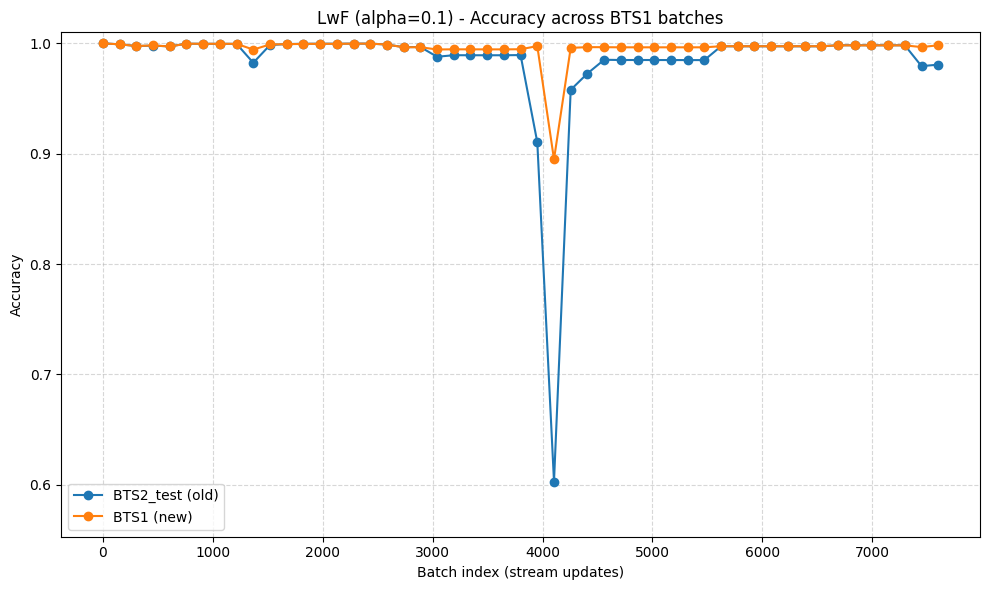

Saved forgetting curve: ../outputs/lwf_alpha_0.1_forgetting_curve.png


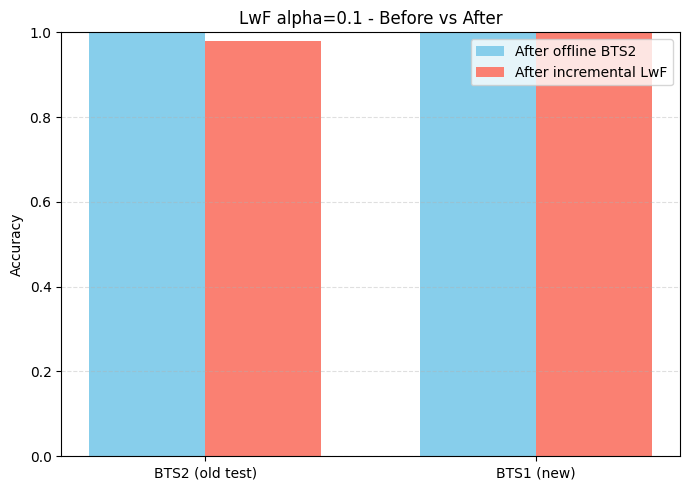

Saved before/after bar: ../outputs/lwf_alpha_0.1_before_after.png
Saved metrics for LwF_alpha_0.1 to ../data/comparison_metrics.json. Final Acc (New): 0.9983
Saved batch CSV: ../outputs/lwf_alpha_0.5_batch_accuracies.csv


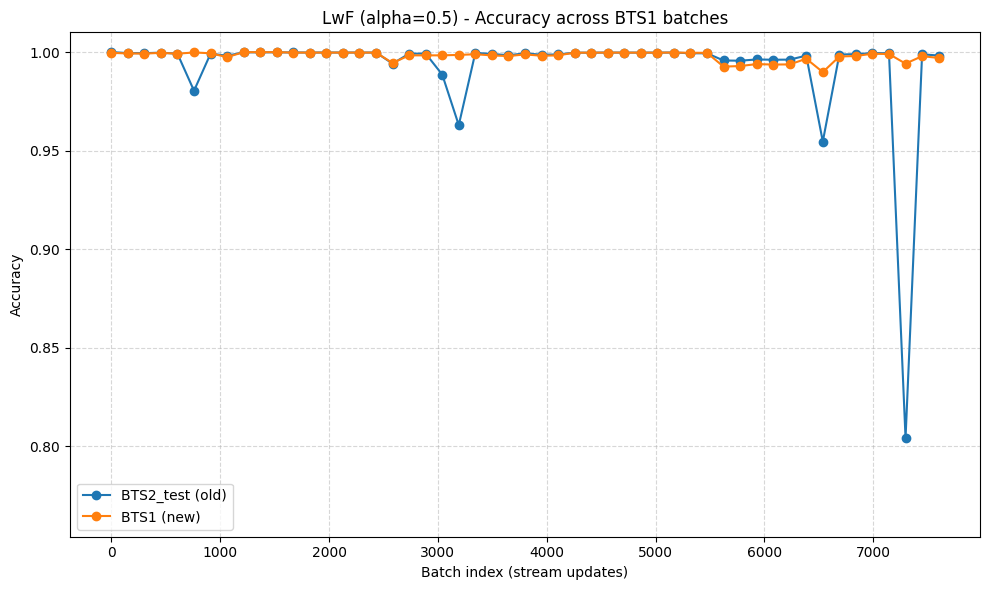

Saved forgetting curve: ../outputs/lwf_alpha_0.5_forgetting_curve.png


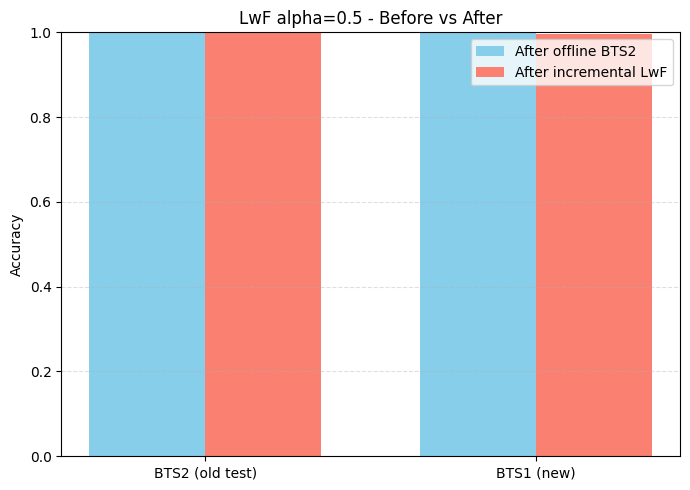

Saved before/after bar: ../outputs/lwf_alpha_0.5_before_after.png
Saved metrics for LwF_alpha_0.5 to ../data/comparison_metrics.json. Final Acc (New): 0.9970
Saved batch CSV: ../outputs/lwf_alpha_0.9_batch_accuracies.csv


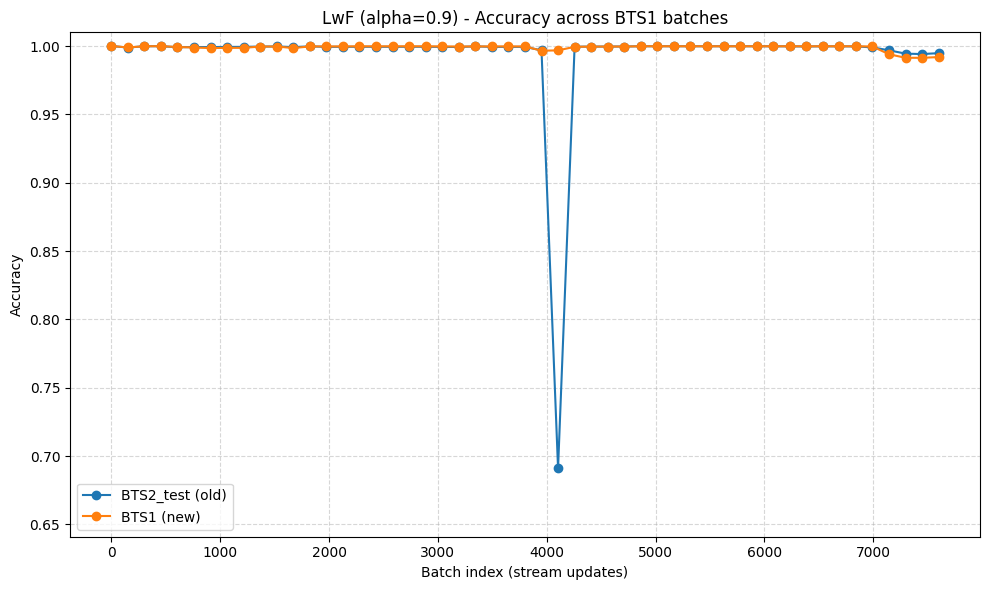

Saved forgetting curve: ../outputs/lwf_alpha_0.9_forgetting_curve.png


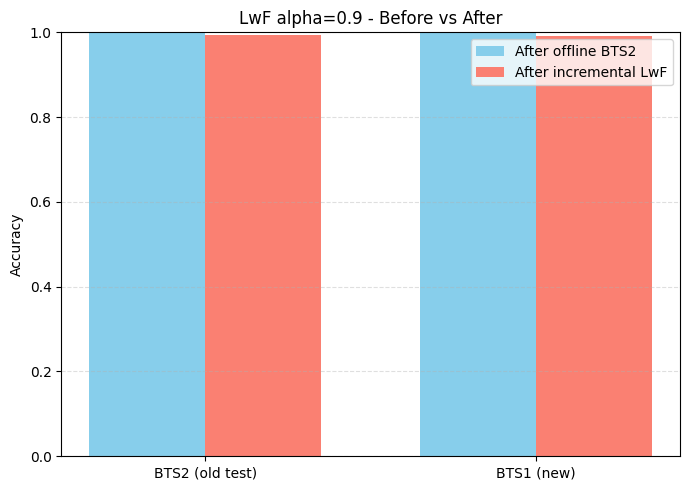

Saved before/after bar: ../outputs/lwf_alpha_0.9_before_after.png
Saved metrics for LwF_alpha_0.9 to ../data/comparison_metrics.json. Final Acc (New): 0.9919


In [ ]:
# Save CSVs, plots, and update comparison_metrics.json

for alpha, res in experiment_results.items():
    # Save batch accuracies CSV
    df_acc = pd.DataFrame({
        "batch_idx": res["batch_idx"],
        "acc_bts2_test": res["acc_old_batches"],
        "acc_bts1": res["acc_new_batches"]
    })
    csv_path = os.path.join(OUT_DIR, f"lwf_alpha_{alpha}_batch_accuracies.csv")
    df_acc.to_csv(csv_path, index=False)
    print("Saved batch CSV:", csv_path)
    
    min_acc_overall = min(min(res["acc_old_batches"]), min(res["acc_new_batches"]))
    y_min_plot = max(0.0, min_acc_overall - 0.05) 

    # Plot forgetting curve
    plt.figure(figsize=(10,6))
    plt.plot(res["batch_idx"], res["acc_old_batches"], '-o', label='BTS2_test (old)')
    plt.plot(res["batch_idx"], res["acc_new_batches"], '-o', label='BTS1 (new)')
    plt.xlabel("Batch index (stream updates)")
    plt.ylabel("Accuracy")
    plt.title(f"LwF (alpha={alpha}) - Accuracy across BTS1 batches")
    
    plt.ylim(y_min_plot,1.01)
    plt.grid(linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    curve_path = os.path.join(OUT_DIR, f"lwf_alpha_{alpha}_forgetting_curve.png")
    plt.savefig(curve_path, dpi=200)
    plt.show()
    print("Saved forgetting curve:", curve_path)


    # Before/after bar:
    initial_old = res["acc_old_initial"]
    initial_new = res["acc_new_initial"]
    final_old = res["acc_old_final"]
    final_new = res["acc_new_final"]
    plt.figure(figsize=(7,5))
    labels = ['BTS2 (old test)', 'BTS1 (new)']
    x = np.arange(len(labels))
    width = 0.35
    plt.bar(x - width/2, [initial_old, initial_new], width, label='After offline BTS2', color='skyblue')
    plt.bar(x + width/2, [final_old, final_new], width, label='After incremental LwF', color='salmon')
    plt.xticks(x, labels)
    plt.ylim(0,1)
    plt.ylabel("Accuracy")
    plt.title(f"LwF alpha={alpha} - Before vs After")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    bar_path = os.path.join(OUT_DIR, f"lwf_alpha_{alpha}_before_after.png")
    plt.savefig(bar_path, dpi=200)
    plt.show()
    print("Saved before/after bar:", bar_path)

    # Update JSON metrics under "LwF" or "LwF_alpha_{alpha}"
    key_name = f"LwF_alpha_{alpha}"
    try:
        with open(METRICS_FILE, 'r') as f:
            metrics_all = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        metrics_all = {}

    metrics_all[key_name] = {
        "accuracy_data": {
            "BTS2 (Old)": float(round(final_old,4)),
            "BTS1 (New)": float(round(final_new,4))
        },
        "metrics_data": {
            "AUROC": res["AUROC"],
            "F1-Score": res["F1"],
            "Forgetting Rate": res["Forgetting_Rate"]
        }
    }

    with open(METRICS_FILE, 'w') as f:
        json.dump(metrics_all, f, indent=4)

    
    print(f"Saved metrics for {key_name} to {METRICS_FILE}. Final Acc (New): {final_new:.4f}")

In [ ]:
# Summary of results
print("=== LwF Summary ===")
for alpha, res in experiment_results.items():
    print(f"\nAlpha = {alpha}")
    print(f"  Initial (teacher) BTS2_test acc: {res['acc_old_initial']:.4f}")
    print(f"  Final BTS2_test acc: {res['acc_old_final']:.4f}")
    print(f"  Final BTS1 acc: {res['acc_new_final']:.4f}")
    print(f"  AUROC: {res['AUROC']}, F1: {res['F1']}, Forgetting Rate: {res['Forgetting_Rate']}")


=== LwF Summary ===

Alpha = 0.1
  Initial (teacher) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9807
  Final BTS1 acc: 0.9983
  AUROC: 0.9804, F1: 0.9904, Forgetting Rate: -0.0158

Alpha = 0.5
  Initial (teacher) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9982
  Final BTS1 acc: 0.9970
  AUROC: 0.9996, F1: 0.9973, Forgetting Rate: 0.0

Alpha = 0.9
  Initial (teacher) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9948
  Final BTS1 acc: 0.9919
  AUROC: 0.9998, F1: 0.9926, Forgetting Rate: -0.0
